## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## PATH:

In [2]:
import os

base_path = "/content/drive/MyDrive/Deep-Learning/Study01/Basic_Preprocessing"

folders = ["dataset", "notebooks", "Visuals"]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folder structure created successfully")

Folder structure created successfully


## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sklearn

print("Libraries imported successfully")

Libraries imported successfully


## Basic Python Check

In [4]:
import sys
print("Python Version:", sys.version)

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## Numpy Array

In [5]:
a = np.array([1, 2, 3, 4])
print("Array:", a)

Array: [1 2 3 4]


## Matrix (Neural Network Weights)

In [6]:
W = np.array([[0.1, 0.2],
              [0.3, 0.4]])

print("Weight Matrix:\n", W)

Weight Matrix:
 [[0.1 0.2]
 [0.3 0.4]]


## Dot Product

In [7]:
x = np.array([1, 2])
w = np.array([0.5, 0.8])

print("Dot Product:", np.dot(x, w))

Dot Product: 2.1


## Line Plot

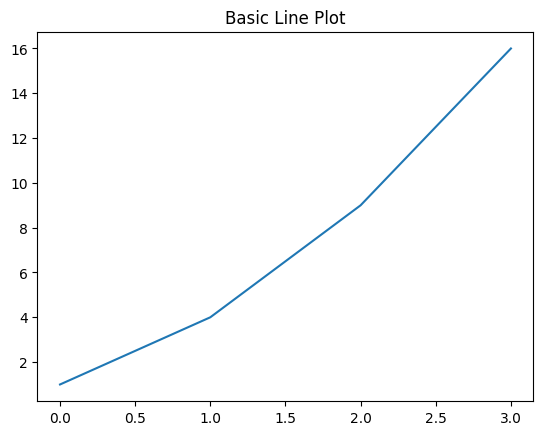

In [8]:
plt.plot([1, 4, 9, 16])
plt.title("Basic Line Plot")

save_path = base_path + "/Visuals/line_plot.png"
plt.savefig(save_path)
plt.show()

## Scatter Plot

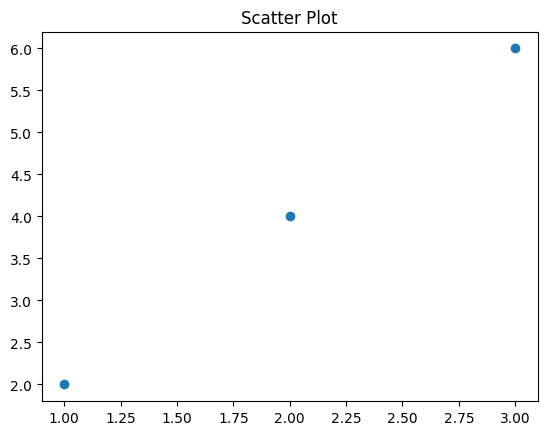

In [9]:
plt.scatter([1,2,3], [2,4,6])
plt.title("Scatter Plot")

save_path = base_path + "/Visuals/scatter_plot.png"
plt.savefig(save_path)
plt.show()

## Download Dataset

In [11]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
save_path = base_path + "/dataset/iris.csv"

urllib.request.urlretrieve(url, save_path)

print("Dataset downloaded successfully")

Dataset downloaded successfully


## Verify file (DataSet)

In [12]:
import os

print(os.listdir(base_path + "/dataset"))

['iris.csv']


## Iris Dataset

In [13]:
file_path = base_path + "/dataset/iris.csv"

data = pd.read_csv(file_path, header=None,
                   names=['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Class'])

data.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Dataset Visualization

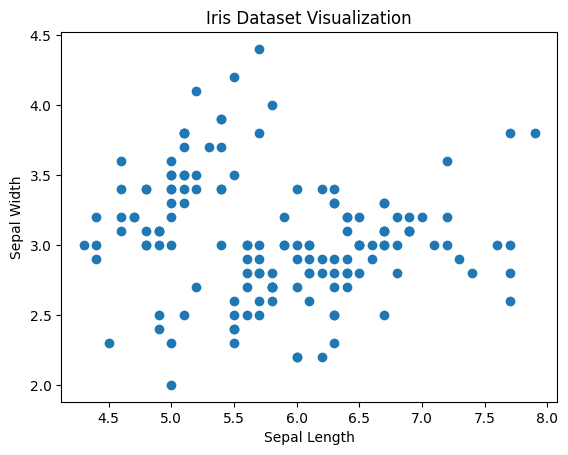

In [14]:
plt.scatter(data['SepalLength'], data['SepalWidth'])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset Visualization")

save_path = base_path + "/Visuals/iris_plot.png"
plt.savefig(save_path)
plt.show()

## images Dataset

In [18]:
dataset_path = base_path + "/dataset/train"

## verify Folder

In [19]:
import os

print("Folders inside train:", os.listdir(dataset_path))

Folders inside train: ['car', 'bike']


## Libraries

In [20]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## Resize image for trainig

In [21]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

## load Dataset

In [22]:
dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Total Images:", len(dataset))
print("Classes:", dataset.classes)

Total Images: 546
Classes: ['bike', 'car']


## Show resized Images

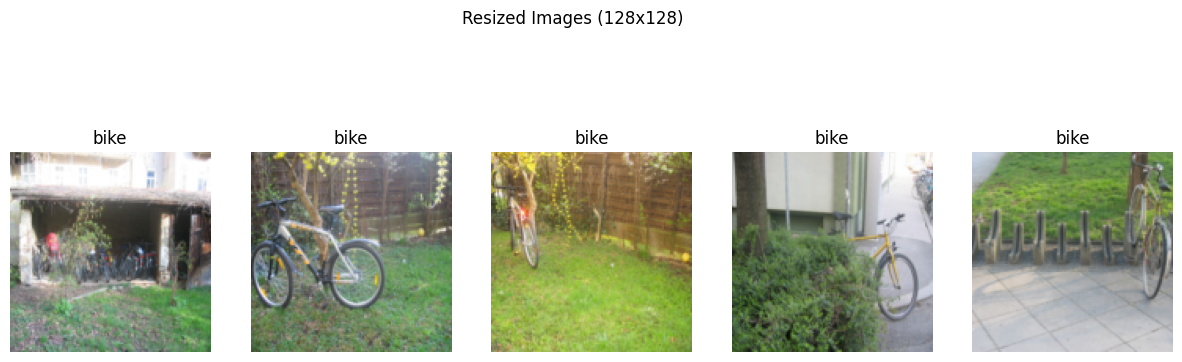

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    img, label = dataset[i]

    axes[i].imshow(img.permute(1,2,0))
    axes[i].set_title(dataset.classes[label])
    axes[i].axis('off')

plt.suptitle("Resized Images (128x128)")

save_path = base_path + "/Visuals/sample_images.png"
plt.savefig(save_path)

plt.show()

## save

In [24]:
import numpy as np

save_dir = base_path + "/Visuals/resized_images"
os.makedirs(save_dir, exist_ok=True)

for i in range(10):
    img, label = dataset[i]

    img_np = img.permute(1,2,0).numpy()

    file_name = f"{dataset.classes[label]}_{i}.png"
    full_path = os.path.join(save_dir, file_name)

    plt.imsave(full_path, img_np)

print("Resized images saved successfully")

Resized images saved successfully


## class Distribution

In [25]:
class_counts = {}

for _, label in dataset:
    class_name = dataset.classes[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

print("Class Distribution:", class_counts)

Class Distribution: {'bike': 252, 'car': 294}


## Plot Distribution

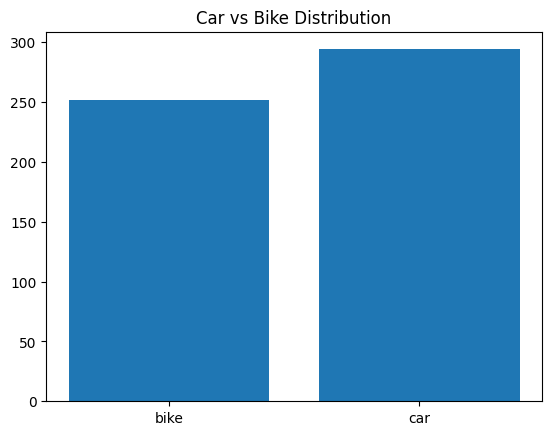

In [26]:
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Car vs Bike Distribution")

save_path = base_path + "/Visuals/class_distribution.png"
plt.savefig(save_path)

plt.show()

## CONCLUSION


- Purpose: To understand basic Python, NumPy, visualization, and dataset handling.
- Achieved: Successfully loaded dataset, created plots, and applied preprocessing.
- Learning: Understood importance of normalization and data preparation.
- Result: Yes, the goal of building foundation for Deep Learning is achieved.
